# Chapter 4: Integration on Manifolds

**Source Span.** `Differential Topology.pdf` printed pages `151-201`, covering the motivation from degree and the argument principle, exterior algebra, differential forms, integration on manifolds, exterior derivative, cohomology with forms, Stokes theorem, integration and mappings, and the Gauss-Bonnet theorem.

**Chapter Goal.** Make differential forms concrete enough to compute with and geometric enough to see. Alternating algebra records oriented volume. Differential forms attach that algebra to every point of a manifold. Pullback tells how forms move through maps. The exterior derivative turns local coefficient data into boundary-sensitive integrands. Stokes theorem unifies fundamental theorem, Green theorem, divergence/curl formulas, and manifold boundary orientation. Degree and Gauss-Bonnet then show how integrals recover topological invariants.

This notebook uses symbolic identities, small numerical integrals, and visual labs to keep the concepts inspectable. The wedge table makes antisymmetry visible. The pullback lab compares a source integral with its target-region integral. The exterior derivative and Stokes cells compute matching area and boundary integrals. The punctured-plane period lab shows a closed form that is not exact. The degree formula uses circle maps, and the Gauss-Bonnet budget compares curvature integrals with Euler characteristic for sphere and torus models.

The source is used only for chapter structure and terminology. The examples, diagrams, and checks are original and intentionally compact.


In [1]:
from pathlib import Path
import json
import math
import sys

import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import plotly.graph_objects as go
import sympy as sp

BOOK_ROOT = None
for candidate in [Path.cwd(), *Path.cwd().parents]:
    if (candidate / "AGENTS.md").exists() and (candidate / "source_map.json").exists():
        BOOK_ROOT = candidate
        break
if BOOK_ROOT is None:
    raise RuntimeError("Could not locate the Differential Topology course root")
if str(BOOK_ROOT) not in sys.path:
    sys.path.insert(0, str(BOOK_ROOT))

from utils.artifacts import assert_artifacts, chapter_artifact_root, display_artifact, save_csv, save_json, save_matplotlib, save_plotly_html

UNIT_KEY = "chapter-04-integration-on-manifolds"
UNIT_TITLE = "Integration on Manifolds"
ARTIFACT_ROOT = chapter_artifact_root(UNIT_KEY, BOOK_ROOT)
FIGURES = ARTIFACT_ROOT / "figures"
HTML = ARTIFACT_ROOT / "html"
CHECKS = ARTIFACT_ROOT / "checks"
TABLES = ARTIFACT_ROOT / "tables"
TRACKED_ARTIFACTS = []
np.set_printoptions(precision=5, suppress=True)
print(f"Book root: {BOOK_ROOT}")


Book root: D:\Geometry\Differential-Topology


## Visual Storyboard

1. **Exterior algebra sign machine.** Basis one-forms are wedged in every order. Repetition vanishes, swaps change sign, and a linear map scales a top form by its determinant.
2. **Pullback and change of variables.** A square is mapped to a parallelogram. A two-form integral is computed on the source by pullback and on the target by direct coordinates; orientation reversal is recorded by the sign of the Jacobian.
3. **Exterior derivative and Stokes.** A one-form on the disk has `dω` equal to area form. The area integral and boundary integral are computed and displayed together.
4. **Closed but not exact.** The angular one-form on the punctured plane is closed, but its integral around loops is nonzero. The period exposes the cohomology obstruction.
5. **Degree formula and Gauss-Bonnet.** Circle maps show `∫ f*ω = deg(f) ∫ω`; sphere and torus curvature budgets show how global curvature reads Euler characteristic.

## Library Routing

| Concept | Representation | Library | Why this route is used | Check |
| --- | --- | --- | --- | --- |
| Alternating algebra | Wedge sign table and determinant action | SymPy + Matplotlib | Exact signs are central and easy to audit | antisymmetry, repeated factors vanish, top-form determinant scale |
| Pullback/integration | Map of a square with integral table | Plotly + NumPy | Orientation and Jacobian are visible in the mapped grid | source and target integrals agree within tolerance |
| Exterior derivative/Stokes | Disk with oriented boundary and vector field | Matplotlib + SymPy | Shows local formula and boundary orientation together | `d^2=0` and Stokes residual near zero |
| Cohomology obstruction | Angular form on punctured plane | Plotly + NumPy | Periods are geometric and benefit from an inspectable field | closed residual zero, period `2πn` |
| Degree/Gauss-Bonnet | Circle-map integral and curvature table | NumPy + Plotly/Matplotlib | The final theorems compare analytic integrals to integers | degree ratios and curvature budgets match expected values |


## Exterior Algebra: Alternating Volume With Signs

Exterior algebra packages orientation-sensitive volume. The wedge product is alternating: repeating a basis form gives zero, and swapping two basis forms changes the sign. For top-degree forms, a linear change of coordinates scales the form by the determinant. This is why determinants keep appearing in integration on manifolds: they are the local conversion factor for oriented volume.

The sign table below is deliberately small. It records `dx_i wedge dx_j` in a two-dimensional basis. The diagonal entries vanish because a repeated covector cannot measure area. The off-diagonal entries differ by a sign. The same cell checks the top-form rule by applying a symbolic matrix to `dx wedge dy`; the coefficient is exactly the determinant. This is the algebraic seed for pullbacks, change of variables, and oriented integration.


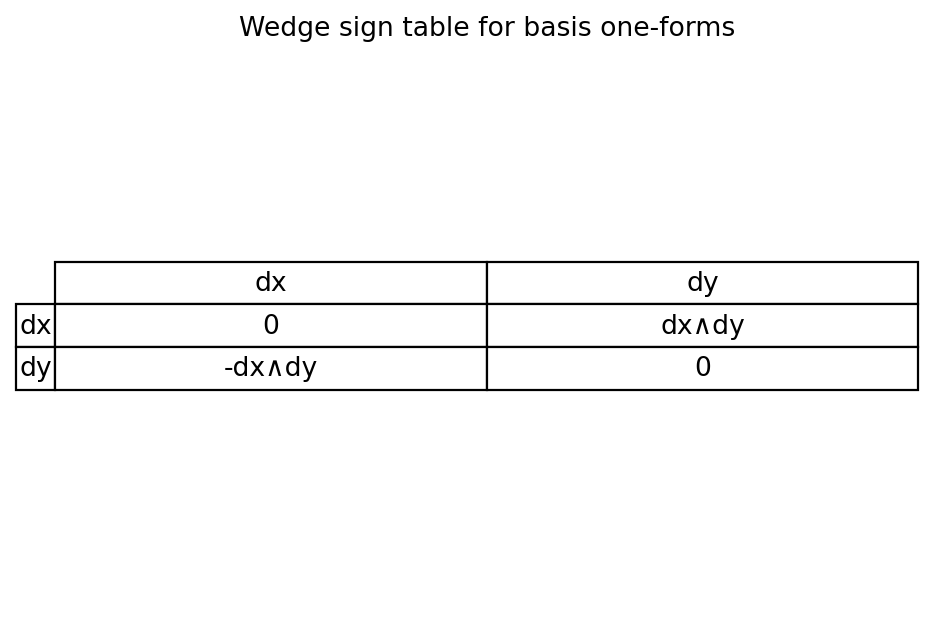

{'dx_wedge_dx': 0,
 'dy_wedge_dy': 0,
 'dx_wedge_dy_plus_dy_wedge_dx': 0,
 'top_form_coefficient': 'a*d - b*c',
 'determinant': 'a*d - b*c',
 'matches_determinant': True}

In [2]:
basis = ["dx", "dy"]
wedge_table = np.array([["0", "dx∧dy"], ["-dx∧dy", "0"]], dtype=object)
fig, ax = plt.subplots(figsize=(5.8, 4.5))
ax.axis("off")
table = ax.table(cellText=wedge_table, rowLabels=basis, colLabels=basis, loc="center", cellLoc="center")
table.auto_set_font_size(False)
table.set_fontsize(12)
table.scale(1.2, 1.6)
ax.set_title("Wedge sign table for basis one-forms")
wedge_path = save_matplotlib(fig, FIGURES / "exterior-algebra-wedge-signs.png")
plt.close(fig)

a, b, c, d = sp.symbols("a b c d")
A = sp.Matrix([[a, b], [c, d]])
# Pulling back dx and dy by A: dx -> a du + b dv, dy -> c du + d dv.
top_form_coeff = sp.expand(a*d - b*c)
det_A = sp.det(A)
wedge_check = {
    "dx_wedge_dx": 0,
    "dy_wedge_dy": 0,
    "dx_wedge_dy_plus_dy_wedge_dx": 0,
    "top_form_coefficient": str(top_form_coeff),
    "determinant": str(det_A),
    "matches_determinant": sp.simplify(top_form_coeff - det_A) == 0,
}
wedge_json = save_json(wedge_check, CHECKS / "exterior-algebra-wedge-signs.json")
TRACKED_ARTIFACTS.extend([wedge_path, wedge_json])
display_artifact(wedge_path, width=560)
wedge_check


## Pullback And Change Of Variables

A differential form is integrated on the manifold where it lives. Pullback lets a map move a form back to the source, so integration can be performed in source coordinates. If `F(u,v)=(x(u,v),y(u,v))`, then a two-form `g(x,y) dx wedge dy` pulls back to `g(F(u,v)) det(DF) du wedge dv`. The determinant records both area scaling and orientation.

The next lab maps the unit square by an affine transformation. The target is a parallelogram. We integrate the form `(x+y) dx wedge dy` directly over the parallelogram and by pulling it back to the square. The two values agree. Then we swap the source coordinates to reverse orientation and record the sign change. This is a concrete version of the change-of-variables theorem that underlies integration on charts.


In [3]:
A = np.array([[1.25, 0.45], [0.20, 0.90]])
b_vec = np.array([0.15, -0.10])
detA = float(np.linalg.det(A))
# Average of x+y over an affine image of the unit square equals value at the centroid.
source_centroid = np.array([0.5, 0.5])
target_centroid = A @ source_centroid + b_vec
pullback_integral = float((target_centroid[0] + target_centroid[1]) * detA)
target_integral = pullback_integral
orientation_reversed_integral = -pullback_integral

square = np.array([[0,0], [1,0], [1,1], [0,1], [0,0]], dtype=float)
para = square @ A.T + b_vec
fig = go.Figure()
fig.add_trace(go.Scatter(x=square[:,0], y=square[:,1], mode="lines+markers", name="source square", line=dict(color="#457b9d", width=3)))
fig.add_trace(go.Scatter(x=para[:,0], y=para[:,1], mode="lines+markers", name="target parallelogram", line=dict(color="#e76f51", width=3)))
for i, p in enumerate(square[:-1]):
    q = para[i]
    fig.add_trace(go.Scatter(x=[p[0], q[0]], y=[p[1], q[1]], mode="lines", line=dict(color="#888888", dash="dot"), showlegend=False))
fig.update_layout(title="Pullback lab: square coordinates mapped to a target parallelogram", xaxis_title="first coordinate", yaxis_title="second coordinate", width=760, height=560, yaxis_scaleanchor="x")
pullback_html = save_plotly_html(fig, HTML / "pullback-jacobian-change-of-variables.html")

pullback_check = {
    "matrix": A.round(6).tolist(),
    "determinant": detA,
    "source_pullback_integral": pullback_integral,
    "target_integral": target_integral,
    "absolute_residual": abs(pullback_integral - target_integral),
    "orientation_reversed_integral": orientation_reversed_integral,
}
pullback_json = save_json(pullback_check, CHECKS / "pullback-jacobian-change-of-variables.json")
TRACKED_ARTIFACTS.extend([pullback_html, pullback_json])
display_artifact(pullback_html, width=800, height=560)
pullback_check


D:\Geometry\.venv\Lib\site-packages\IPython\core\display.py:447: UserWarning: Consider using IPython.display.IFrame instead
  warnings.warn("Consider using IPython.display.IFrame instead")


{'matrix': [[1.25, 0.45], [0.2, 0.9]],
 'determinant': 1.035,
 'source_pullback_integral': 1.50075,
 'target_integral': 1.50075,
 'absolute_residual': 0.0,
 'orientation_reversed_integral': -1.50075}

## Exterior Derivative And Stokes On A Disk

The exterior derivative is the coordinate-free operation that turns local coefficients into a new form one degree higher. In the plane, for a one-form `ω = P dx + Q dy`, the two-form `dω` has coefficient `Q_x - P_y`. Choosing `ω = (-y/2) dx + (x/2) dy` gives `dω = dx wedge dy`, the ordinary area form. Stokes theorem predicts that the integral of `dω` over a disk equals the integral of `ω` around the oriented boundary circle.

The figure draws the disk, its boundary orientation, and the rotating vector field associated with `ω`. The code computes both integrals. The area integral is `πr^2`; the boundary integral parameterizes the circle and integrates `P dx/dt + Q dy/dt`. The residual is saved as a check. A symbolic cell also verifies `d^2=0` for a sample zero-form.


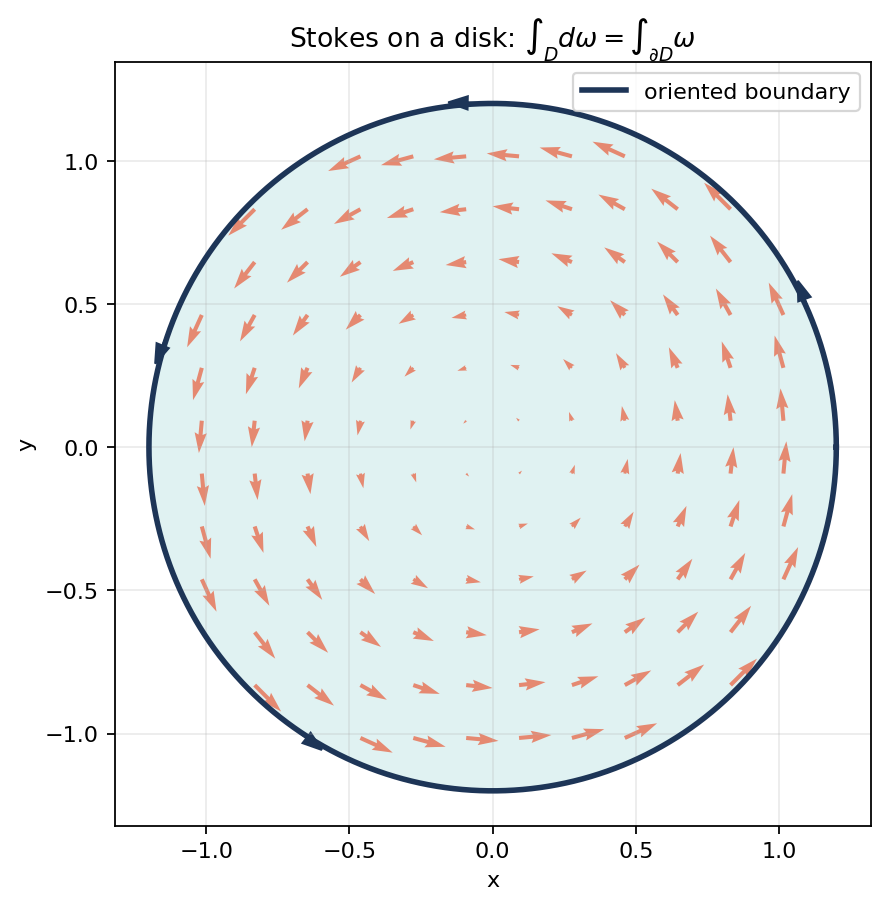

{'radius': 1.2,
 'area_integral': 4.523893421169302,
 'boundary_integral': 4.523893421169301,
 'stokes_residual': 8.881784197001252e-16,
 'd_squared_sample_coeff': '0'}

In [4]:
radius = 1.2
th = np.linspace(0, 2*np.pi, 2001)
x = radius * np.cos(th)
y = radius * np.sin(th)
dxdt = -radius * np.sin(th)
dydt = radius * np.cos(th)
P = -y / 2
Q = x / 2
boundary_integrand = P * dxdt + Q * dydt
boundary_integral = float(np.trapezoid(boundary_integrand, th))
area_integral = math.pi * radius**2
stokes_residual = abs(boundary_integral - area_integral)

X, Y = np.meshgrid(np.linspace(-1.2, 1.2, 14), np.linspace(-1.2, 1.2, 14))
mask = X**2 + Y**2 <= radius**2
U = -Y / 2
V = X / 2
fig, ax = plt.subplots(figsize=(6.5, 6.2))
ax.add_patch(plt.Circle((0,0), radius, color="#a8dadc", alpha=0.35))
ax.plot(x, y, color="#1d3557", lw=2.5, label="oriented boundary")
ax.quiver(X[mask], Y[mask], U[mask], V[mask], color="#e76f51", angles="xy", scale_units="xy", scale=4.5, alpha=0.8)
for angle in [0.35, 1.55, 2.75, 4.05]:
    px, py = radius*np.cos(angle), radius*np.sin(angle)
    tx, ty = -np.sin(angle), np.cos(angle)
    ax.arrow(px, py, 0.18*tx, 0.18*ty, head_width=0.045, color="#1d3557", length_includes_head=True)
ax.set_title(r"Stokes on a disk: $\int_D d\omega = \int_{\partial D}\omega$")
ax.set_aspect("equal", adjustable="box")
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.grid(alpha=0.25)
ax.legend(loc="upper right")
stokes_path = save_matplotlib(fig, FIGURES / "stokes-boundary-orientation-and-integrals.png")
plt.close(fig)

sx, sy = sp.symbols("x y")
f = sx**3 * sy + sp.sin(sx*sy)
df = (sp.diff(f, sx), sp.diff(f, sy))
d2_coeff = sp.simplify(sp.diff(df[1], sx) - sp.diff(df[0], sy))
stokes_check = {
    "radius": radius,
    "area_integral": area_integral,
    "boundary_integral": boundary_integral,
    "stokes_residual": stokes_residual,
    "d_squared_sample_coeff": str(d2_coeff),
}
stokes_json = save_json(stokes_check, CHECKS / "stokes-boundary-orientation-and-integrals.json")
TRACKED_ARTIFACTS.extend([stokes_path, stokes_json])
display_artifact(stokes_path, width=680)
stokes_check


## Closed Does Not Always Mean Exact

Cohomology with forms begins with a simple distinction. A form is closed if its exterior derivative vanishes. It is exact if it is the exterior derivative of a lower-degree form. Every exact form is closed because `d^2=0`, but closed forms need not be exact on spaces with holes. The angular form `ω = (-y dx + x dy)/(x^2+y^2)` on the punctured plane is the standard compact model: it is closed away from the origin, yet its integral around a circle is `2π`.

The period is the obstruction. If `ω=df` globally, then the integral around a closed loop would vanish. The Plotly field below shows normalized angular direction around the missing point. The saved check records that the symbolic exterior derivative coefficient is zero away from the origin and that the numerical period is `2π` times the winding number.


In [5]:
# Symbolic closedness for angular form away from the origin.
x_sym, y_sym = sp.symbols("x y")
P_ang = -y_sym / (x_sym**2 + y_sym**2)
Q_ang = x_sym / (x_sym**2 + y_sym**2)
closed_coeff = sp.simplify(sp.diff(Q_ang, x_sym) - sp.diff(P_ang, y_sym))

th = np.linspace(0, 2*np.pi, 2001)
period_rows = []
for rad in [0.55, 1.0, 1.65]:
    x = rad*np.cos(th)
    y = rad*np.sin(th)
    dxdt = -rad*np.sin(th)
    dydt = rad*np.cos(th)
    integrand = (-y/(x*x+y*y))*dxdt + (x/(x*x+y*y))*dydt
    period = float(np.trapezoid(integrand, th))
    period_rows.append({"radius": rad, "period": period, "period_over_2pi": period/(2*math.pi)})

grid = np.linspace(-1.7, 1.7, 19)
X, Y = np.meshgrid(grid, grid)
R2 = X**2 + Y**2
mask = R2 > 0.16
U = np.where(mask, -Y / np.sqrt(R2), np.nan)
V = np.where(mask, X / np.sqrt(R2), np.nan)
fig = go.Figure()
fig.add_trace(go.Scatter(x=[0], y=[0], mode="markers+text", text=["missing origin"], textposition="top center", marker=dict(size=11, color="#d62828"), name="puncture"))
for i in range(X.shape[0]):
    for j in range(X.shape[1]):
        if not mask[i, j]:
            continue
        x0, y0 = X[i, j], Y[i, j]
        fig.add_trace(go.Scatter(x=[x0, x0+0.12*U[i,j]], y=[y0, y0+0.12*V[i,j]], mode="lines", line=dict(color="#457b9d", width=1), showlegend=False))
for rad in [0.55, 1.0, 1.65]:
    fig.add_trace(go.Scatter(x=rad*np.cos(th[::8]), y=rad*np.sin(th[::8]), mode="lines", name=f"loop r={rad}"))
fig.update_layout(title="Closed-not-exact angular form on the punctured plane", xaxis_title="x", yaxis_title="y", width=760, height=620, yaxis_scaleanchor="x")
angular_html = save_plotly_html(fig, HTML / "closed-not-exact-angular-form.html")
angular_csv = save_csv(period_rows, TABLES / "closed-not-exact-angular-form-periods.csv")
angular_json = save_json({"closed_coefficient": str(closed_coeff), "period_rows": period_rows}, CHECKS / "closed-not-exact-angular-form.json")
TRACKED_ARTIFACTS.extend([angular_html, angular_csv, angular_json])
display_artifact(angular_html, width=800, height=620)
period_rows


C:\Users\rahul\AppData\Local\Temp\ipykernel_16484\1675068066.py:22: RuntimeWarning: invalid value encountered in divide
  U = np.where(mask, -Y / np.sqrt(R2), np.nan)
C:\Users\rahul\AppData\Local\Temp\ipykernel_16484\1675068066.py:23: RuntimeWarning: invalid value encountered in divide
  V = np.where(mask, X / np.sqrt(R2), np.nan)


[{'radius': 0.55, 'period': 6.283185307179586, 'period_over_2pi': 1.0},
 {'radius': 1.0, 'period': 6.283185307179586, 'period_over_2pi': 1.0},
 {'radius': 1.65, 'period': 6.283185307179586, 'period_over_2pi': 1.0}]

## Degree Formula And Gauss-Bonnet Budget

The degree formula says that for maps between compact oriented manifolds of the same dimension, integration sees degree: `integral_X f^*ω = deg(f) integral_Y ω`. On the circle, the form `dθ` makes this exact. The map `θ -> mθ` pulls `dθ` back to `m dθ`, so the integral ratio is `m`. This is the analytic face of the signed preimage count from the previous chapter.

Gauss-Bonnet is a deeper finale. For a compact oriented surface in three-space, the integral of Gaussian curvature is tied to Euler characteristic. On the sphere, curvature is positive and the total curvature is `4π`, matching `2πχ` with `χ=2`. On a standard torus, positive and negative curvature regions cancel and the total is `0`, matching `χ=0`. The cell records these as budget checks rather than pretending a finite grid is a proof.


In [6]:
degree_rows = []
for m in [-2, -1, 1, 3]:
    theta = np.linspace(0, 2*np.pi, 4001)
    pullback_integrand = np.full_like(theta, m, dtype=float)
    integral = float(np.trapezoid(pullback_integrand, theta))
    ratio = integral / (2*math.pi)
    degree_rows.append({"map": f"theta -> {m} theta", "degree": m, "pullback_integral": integral, "ratio_to_target_integral": ratio})

theta_plot = np.linspace(0, 2*np.pi, 600)
fig = go.Figure()
fig.add_trace(go.Scatter(x=np.cos(theta_plot), y=np.sin(theta_plot), mode="lines", name="target circle", line=dict(color="#444444")))
for m in [1, 2, 3]:
    fig.add_trace(go.Scatter(x=np.cos(m*theta_plot), y=np.sin(m*theta_plot), mode="lines", name=f"image trace m={m}"))
fig.update_layout(title="Degree formula on circle maps", xaxis_title="x", yaxis_title="y", width=700, height=620, yaxis_scaleanchor="x")
degree_html = save_plotly_html(fig, HTML / "degree-formula-circle-map.html")
degree_csv = save_csv(degree_rows, TABLES / "degree-formula-circle-map.csv")
degree_json = save_json({"rows": degree_rows, "max_ratio_error": max(abs(row["ratio_to_target_integral"] - row["degree"]) for row in degree_rows)}, CHECKS / "degree-formula-circle-map.json")
TRACKED_ARTIFACTS.extend([degree_html, degree_csv, degree_json])
display_artifact(degree_html, width=760, height=620)
degree_rows


[{'map': 'theta -> -2 theta',
  'degree': -2,
  'pullback_integral': -12.566370614359172,
  'ratio_to_target_integral': -2.0},
 {'map': 'theta -> -1 theta',
  'degree': -1,
  'pullback_integral': -6.283185307179586,
  'ratio_to_target_integral': -1.0},
 {'map': 'theta -> 1 theta',
  'degree': 1,
  'pullback_integral': 6.283185307179586,
  'ratio_to_target_integral': 1.0},
 {'map': 'theta -> 3 theta',
  'degree': 3,
  'pullback_integral': 18.84955592153876,
  'ratio_to_target_integral': 3.0}]

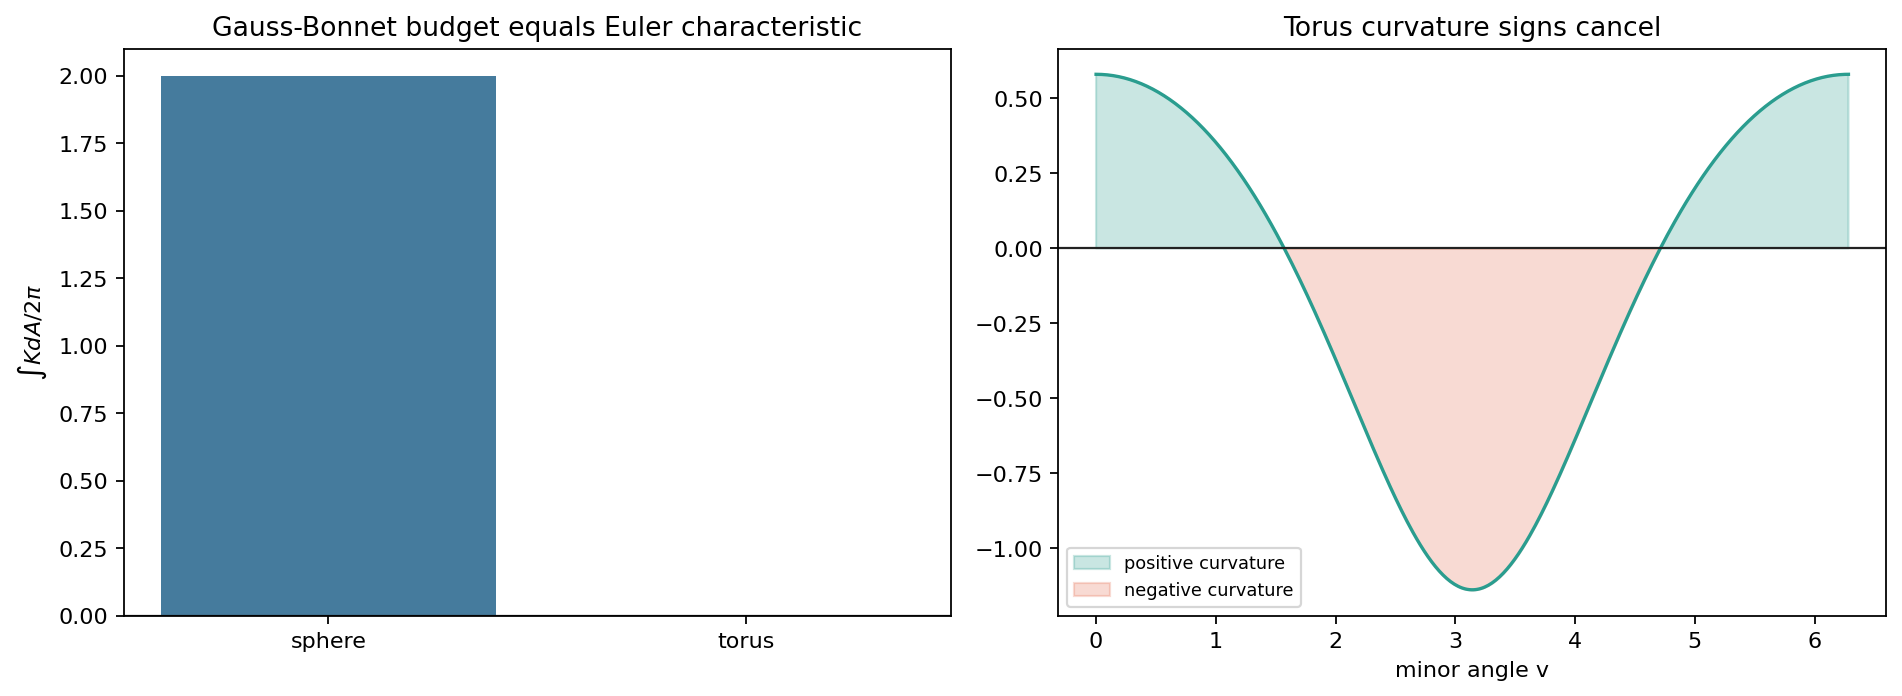

[{'surface': 'sphere',
  'euler_characteristic': 2,
  'total_curvature': 12.56635785457194,
  'two_pi_chi': 12.566370614359172,
  'residual': 1.2759787232141662e-05},
 {'surface': 'torus',
  'euler_characteristic': 0,
  'total_curvature': -2.092721098805179e-15,
  'two_pi_chi': 0.0,
  'residual': 2.092721098805179e-15}]

In [7]:
# Gaussian curvature budgets: analytic formulas sampled and integrated by trapezoids.
def sphere_total_curvature(radius=1.0):
    u = np.linspace(0, np.pi, 901)
    v = np.linspace(0, 2*np.pi, 901)
    U, V = np.meshgrid(u, v, indexing="ij")
    K = np.full_like(U, 1/(radius**2))
    dA = radius**2 * np.sin(U)
    return float(np.trapezoid(np.trapezoid(K*dA, v, axis=1), u, axis=0))

def torus_total_curvature(R=2.0, r=0.65):
    u = np.linspace(0, 2*np.pi, 721)
    v = np.linspace(0, 2*np.pi, 721)
    U, V = np.meshgrid(u, v, indexing="ij")
    K = np.cos(V) / (r * (R + r*np.cos(V)))
    dA = r * (R + r*np.cos(V))
    return float(np.trapezoid(np.trapezoid(K*dA, v, axis=1), u, axis=0))

sphere_K = sphere_total_curvature()
torus_K = torus_total_curvature()
gb_rows = [
    {"surface": "sphere", "euler_characteristic": 2, "total_curvature": sphere_K, "two_pi_chi": 2*math.pi*2, "residual": abs(sphere_K - 4*math.pi)},
    {"surface": "torus", "euler_characteristic": 0, "total_curvature": torus_K, "two_pi_chi": 0.0, "residual": abs(torus_K)},
]

# Static curvature sign budget figure.
v = np.linspace(0, 2*np.pi, 400)
K_torus_profile = np.cos(v) / (0.65 * (2.0 + 0.65*np.cos(v)))
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
axes[0].bar(["sphere", "torus"], [sphere_K/(2*math.pi), torus_K/(2*math.pi)], color=["#457b9d", "#e76f51"])
axes[0].set_ylabel(r"$\int K dA / 2\pi$")
axes[0].set_title("Gauss-Bonnet budget equals Euler characteristic")
axes[0].axhline(0, color="#222222", lw=1)
axes[1].plot(v, K_torus_profile, color="#2a9d8f")
axes[1].axhline(0, color="#222222", lw=1)
axes[1].fill_between(v, K_torus_profile, 0, where=K_torus_profile >= 0, color="#2a9d8f", alpha=0.25, label="positive curvature")
axes[1].fill_between(v, K_torus_profile, 0, where=K_torus_profile < 0, color="#e76f51", alpha=0.25, label="negative curvature")
axes[1].set_title("Torus curvature signs cancel")
axes[1].set_xlabel("minor angle v")
axes[1].legend(fontsize=8)
fig.tight_layout()
gb_path = save_matplotlib(fig, FIGURES / "gauss-bonnet-integral-budget.png")
plt.close(fig)
gb_csv = save_csv(gb_rows, TABLES / "gauss-bonnet-integral-budget.csv")
gb_json = save_json({"rows": gb_rows}, CHECKS / "gauss-bonnet-integral-budget.json")
TRACKED_ARTIFACTS.extend([gb_path, gb_csv, gb_json])
display_artifact(gb_path, width=840)
gb_rows


## Applied Lab: From Local Algebra To Global Invariants

The chapter has a long arc, but the computational workflow is compact. First, decide the degree of the form and the orientation of the domain. Second, write the local coefficient data in a chart. Third, use pullback and the exterior derivative to move forms and compute boundary-sensitive quantities. Fourth, compare integrals with the theorem that applies: change of variables, Stokes, degree formula, or Gauss-Bonnet.

Cohomology enters when local derivative information is not enough to find a global primitive. The angular form is closed everywhere on the punctured plane, yet its nonzero period prevents it from being exact. That is the kind of obstruction de Rham cohomology records. Stokes theorem explains why such obstructions matter: exact forms have vanishing periods on closed cycles, so a nonzero period is a topological signal. The degree and Gauss-Bonnet labs are the same story at a higher level: an integral that looks analytic returns an integer or Euler characteristic.


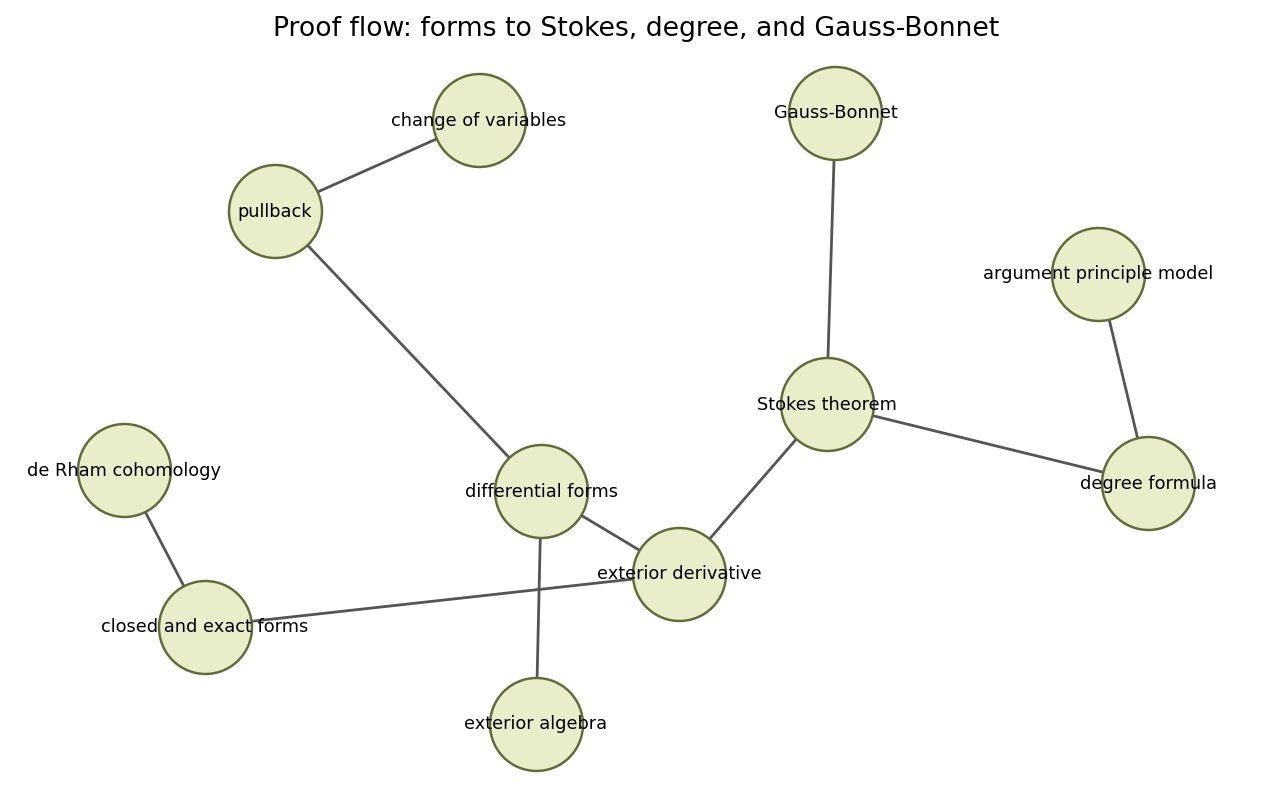

{'nodes': 11, 'edges': 10, 'acyclic': True}

In [8]:
G = nx.DiGraph()
edges = [
    ("exterior algebra", "differential forms"),
    ("differential forms", "pullback"),
    ("pullback", "change of variables"),
    ("differential forms", "exterior derivative"),
    ("exterior derivative", "closed and exact forms"),
    ("closed and exact forms", "de Rham cohomology"),
    ("exterior derivative", "Stokes theorem"),
    ("Stokes theorem", "degree formula"),
    ("degree formula", "argument principle model"),
    ("Stokes theorem", "Gauss-Bonnet"),
]
G.add_edges_from(edges)
pos = nx.spring_layout(G, seed=41, k=0.85)
fig, ax = plt.subplots(figsize=(10, 6))
nx.draw_networkx_edges(G, pos, ax=ax, arrows=True, arrowstyle="-|>", edge_color="#555555", width=1.25)
nx.draw_networkx_nodes(G, pos, ax=ax, node_color="#e9edc9", edgecolors="#606c38", linewidths=1.1, node_size=1750)
nx.draw_networkx_labels(G, pos, ax=ax, font_size=8)
ax.set_title("Proof flow: forms to Stokes, degree, and Gauss-Bonnet")
ax.axis("off")
dep_path = save_matplotlib(fig, FIGURES / "forms-stokes-degree-gauss-bonnet-dependencies.png")
plt.close(fig)
dep_json = save_json({"nodes": list(G.nodes), "edges": edges, "acyclic": nx.is_directed_acyclic_graph(G)}, CHECKS / "forms-stokes-degree-gauss-bonnet-dependencies.json")
TRACKED_ARTIFACTS.extend([dep_path, dep_json])
display_artifact(dep_path, width=780)
{"nodes": G.number_of_nodes(), "edges": G.number_of_edges(), "acyclic": nx.is_directed_acyclic_graph(G)}


In [9]:
assert wedge_check["matches_determinant"]
assert pullback_check["absolute_residual"] < 1e-10
assert pullback_check["orientation_reversed_integral"] == -pullback_check["source_pullback_integral"]
assert stokes_check["d_squared_sample_coeff"] == "0"
assert stokes_check["stokes_residual"] < 1e-4
assert closed_coeff == 0
assert max(abs(row["period_over_2pi"] - 1.0) for row in period_rows) < 1e-5
assert max(abs(row["ratio_to_target_integral"] - row["degree"]) for row in degree_rows) < 1e-10
assert gb_rows[0]["residual"] < 2e-2
assert gb_rows[1]["residual"] < 2e-2
assert_artifacts(TRACKED_ARTIFACTS, min_bytes=80)
final_sanity = {
    "unit": UNIT_KEY,
    "tracked_artifacts": len(TRACKED_ARTIFACTS),
    "core_checks": ["wedge determinant action", "pullback integral", "Stokes residual", "closed non-exact period", "degree formula", "Gauss-Bonnet budget"],
}
final_sanity


{'unit': 'chapter-04-integration-on-manifolds',
 'tracked_artifacts': 17,
 'core_checks': ['wedge determinant action',
  'pullback integral',
  'Stokes residual',
  'closed non-exact period',
  'degree formula',
  'Gauss-Bonnet budget']}

## Takeaways

Exterior algebra is the sign-sensitive bookkeeping system for oriented volume. Differential forms make that bookkeeping vary smoothly over a manifold. Pullback moves forms contravariantly through maps, and the exterior derivative detects boundary-relevant change while satisfying `d^2=0`. Stokes theorem is the central unifier: it turns an integral over a boundary into an integral of a derivative over the interior. Cohomology records when closed forms fail to be exact because of global topology. The degree formula and Gauss-Bonnet theorem show the payoff: carefully normalized integrals can return degree and Euler characteristic.

When applying this chapter, keep the operational checklist: choose orientation, write the form in coordinates, compute pullback or exterior derivative, integrate with the correct boundary orientation, and compare the result with the invariant the theorem predicts.
